<a href="https://colab.research.google.com/github/lilswapnil/moviez/blob/main/recommender/notebook/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Cleaning & Preprocessing

In [1]:
import kagglehub
import pandas as pd
import numpy as np

In [2]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

100%|██████████| 236M/236M [00:02<00:00, 89.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/849


In [3]:
moviez = pd.read_csv(f"{path}/TMDB_movie_dataset_v11.csv")
moviez.shape

(1372289, 24)

In [4]:
moviez

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372284,848021,amsterdam groot,0.000,0,Released,NaN,0,0,False,NaN,...,amsterdam groot,NaN,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1372285,848022,Dionne Warwick: Souled Out,0.000,0,Released,1969-09-17,0,60,False,NaN,...,Dionne Warwick: Souled Out,CBS Television with Warwick's guests Burt Bach...,0.7600,/my3ZcFLPZWi4pytw8kmTmMcdK5b.jpg,NaN,Music,NaN,NaN,English,NaN
1372286,848023,Lynda Carter: Encore!,0.000,0,Released,1980-09-16,0,50,False,NaN,...,Lynda Carter: Encore!,Lynda Carter's second musical TV special.,0.6000,/knw2gVPcej7iJPEoJUrtJOXBsjg.jpg,NaN,"Music, TV Movie",Lyn-Ron Productions Inc.,United States of America,English,"variety show, variety special"
1372287,848026,23-04-2016 Volleyball,0.000,0,Released,2016-04-23,0,0,False,NaN,...,23-04-2016 Volleyball,23-04-2016 Volleyball,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


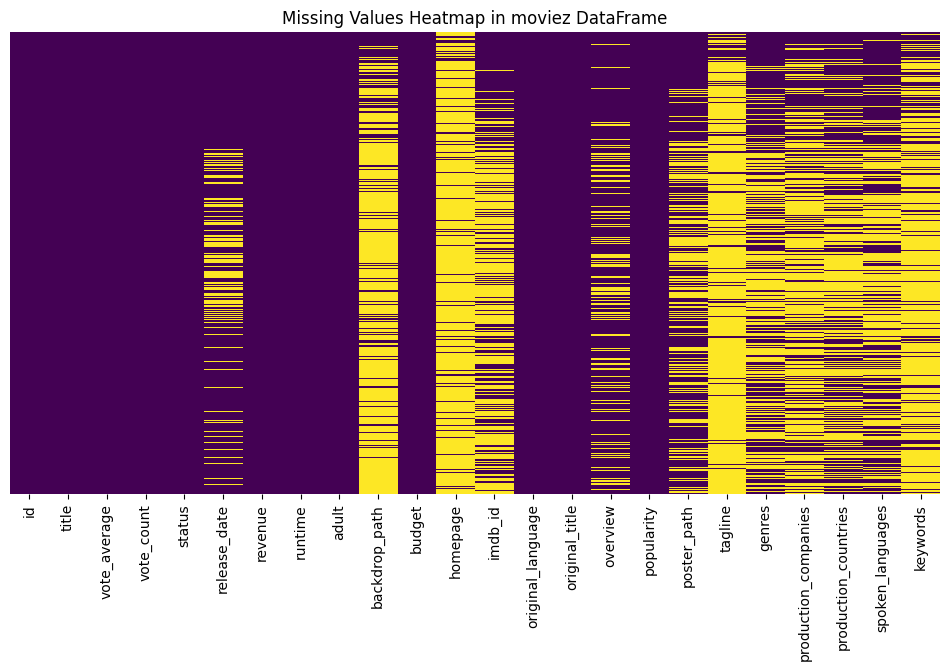

In [5]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(moviez.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap in moviez DataFrame')
plt.show()

In [6]:
#drop the columns that are not needed
cleaned_moviez = moviez.drop(columns=['revenue', 'budget', 'homepage', 'original_language', 'runtime', 'backdrop_path', 'production_companies', 'production_countries'])
cleaned_moviez.shape


(1372289, 16)

In [7]:
cleaned_moviez.head()

,id,title,vote_average,vote_count,status,release_date,adult,imdb_id,original_title,overview,popularity,poster_path,tagline,genres,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,False,tt1375666,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,False,tt0816692,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,False,tt0468569,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,False,tt0499549,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,False,tt0848228,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure","English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [8]:
#drop the rows the has null values in genre, original_title, overview
cleaned_moviez = cleaned_moviez[cleaned_moviez['genres'].notna()]
cleaned_moviez = cleaned_moviez[cleaned_moviez['original_title'].notna()]
cleaned_moviez = cleaned_moviez[cleaned_moviez['overview'].notna()]

In [9]:
cleaned_moviez.shape

(637060, 16)

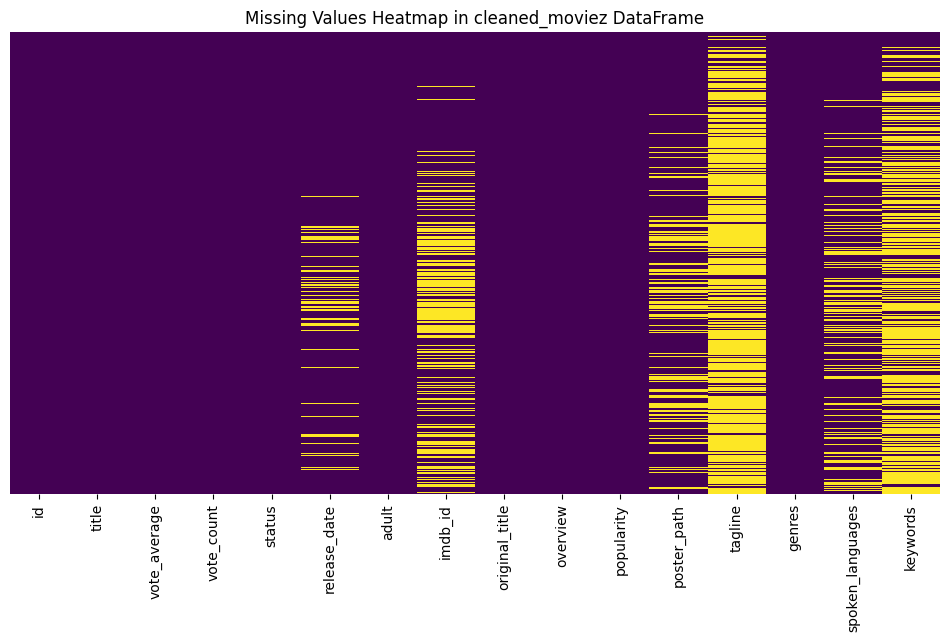

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cleaned_moviez.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap in cleaned_moviez DataFrame')
plt.show()

In [11]:
cleaned_moviez.head()

,id,title,vote_average,vote_count,status,release_date,adult,imdb_id,original_title,overview,popularity,poster_path,tagline,genres,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,False,tt1375666,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,False,tt0816692,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,False,tt0468569,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,False,tt0499549,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,False,tt0848228,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure","English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [34]:
#save the cleaned dataset to a new csv file
cleaned_moviez.to_csv('moviez_dataset.csv', index=False)

# Recommendation Dataset

In [23]:
#drop the columns that are not needed for recommendation system
moviez_dataset = cleaned_moviez.drop(columns=['adult', 'release_date', 'status', 'title', 'imdb_id', 'poster_path', 'tagline', 'keywords'])
moviez_dataset.shape

(637060, 8)

In [24]:
moviez_dataset.head()

,id,vote_average,vote_count,original_title,overview,popularity,genres,spoken_languages
0,27205,8.364,34495,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili"
1,157336,8.417,32571,Interstellar,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction",English
2,155,8.512,30619,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","English, Mandarin"
3,19995,7.573,29815,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","English, Spanish"
4,24428,7.710,29166,The Avengers,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure","English, Hindi, Russian"


In [25]:
# calculate relative votes
moviez_dataset['rating'] = (moviez_dataset['vote_count'] / moviez_dataset['vote_count'].max())*100
moviez_dataset.head()

,id,vote_average,vote_count,original_title,overview,popularity,genres,spoken_languages,rating
0,27205,8.364,34495,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili",100.000000
1,157336,8.417,32571,Interstellar,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction",English,94.422380
2,155,8.512,30619,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","English, Mandarin",88.763589
3,19995,7.573,29815,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","English, Spanish",86.432816
4,24428,7.710,29166,The Avengers,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure","English, Hindi, Russian",84.551384


In [26]:
#drop unnecessary columns
moviez_dataset = moviez_dataset.drop(columns=['vote_count', 'vote_average'])

In [27]:
#drop movies with no spoken languages
moviez_dataset = moviez_dataset.drop(moviez_dataset[moviez_dataset['spoken_languages'].isna()].index)
moviez_dataset.shape

(479876, 7)

In [28]:
#drop movies with 0 ratings and 0 popularity
moviez_dataset = moviez_dataset.drop(moviez_dataset[(moviez_dataset['rating'] == 0) & (moviez_dataset['popularity'] == 0)].index)
moviez_dataset.shape

(460370, 7)

In [29]:
#drop movies with overview less than 25 characters
short_overview_movies = moviez_dataset[moviez_dataset['overview'].str.len() < 25]
moviez_dataset = moviez_dataset.drop(short_overview_movies.index)
moviez_dataset.shape

(454840, 7)

In [30]:
#drop movies with less than 1 rating
zero_rating_movies = moviez_dataset[moviez_dataset['rating'] < 1]
moviez_dataset = moviez_dataset.drop(zero_rating_movies.index)
moviez_dataset.shape

(8199, 7)

In [32]:
moviez_dataset

,id,original_title,overview,popularity,genres,spoken_languages,rating
0,27205,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili",100.000000
1,157336,Interstellar,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction",English,94.422380
2,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","English, Mandarin",88.763589
3,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","English, Spanish",86.432816
4,24428,The Avengers,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure","English, Hindi, Russian",84.551384
...,...,...,...,...,...,...,...
8201,273169,Sous les jupes des filles,A story about 11 girls living in Paris. Each o...,8.066,Comedy,French,1.000145
8202,43939,I'm Still Here,I'm Still Here is a portrayal of a tumultuous ...,12.553,"Music, Comedy, Drama",English,1.000145
8203,15014,Bianca,"Eccentric and full of manias, Michele is a you...",6.185,"Drama, Comedy",Italian,1.000145
8204,652004,The Wolf of Snow Hollow,A stressed-out police officer struggles not to...,11.189,"Horror, Thriller",English,1.000145


In [33]:
#save the cleaned dataset to a new csv file
moviez_dataset.to_csv('cleaned_moviez_dataset.csv', index=False)